In [ ]:
from pathlib import Path
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

DATA_PATHS = [
    Path("../data/raw/laptops_cleaned.csv"),
    Path("data/raw/laptops_cleaned.csv"),
]
# Try to find the data file in the specified paths
data_path = next((p for p in DATA_PATHS if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find laptops_cleaned.csv in the expected locations.")

df = pd.read_csv(data_path)

target = "price"
# Define the feature set (ex the target variable)
feature_set_a = [
    "brand",
    "device_category",
    "rating",
    "cpu_brand",
    "cpu_family",
    "cpu_core_count",
    "cpu_thread_count",
    "ram_gb",
    "storage_gb",
    "display_width_px",
    "display_height_px",
    "display_size_inch",
    "gpu_brand",
    "gpu_type",
    "gpu_vram_gb",
    "os_name",
    "warranty_years",
]
# Check for missing columns in the DataFrame
missing_columns = sorted(set(feature_set_a + [target]) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")
# Prepare feature matrix X and target vector y
X = df[feature_set_a].copy()
y = df[target].copy()
# Print the shapes of X and y, and the feature columns
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

X shape: (992, 17)
y shape: (992,)

Feature columns:
['brand', 'device_category', 'rating', 'cpu_brand', 'cpu_family', 'cpu_core_count', 'cpu_thread_count', 'ram_gb', 'storage_gb', 'display_width_px', 'display_height_px', 'display_size_inch', 'gpu_brand', 'gpu_type', 'gpu_vram_gb', 'os_name', 'warranty_years']


In [ ]:
# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['rating', 'cpu_core_count', 'cpu_thread_count', 'ram_gb', 'storage_gb', 'display_width_px', 'display_height_px', 'display_size_inch', 'gpu_vram_gb', 'warranty_years']

Categorical features:
['brand', 'device_category', 'cpu_brand', 'cpu_family', 'gpu_brand', 'gpu_type', 'os_name']


In [ ]:
# Check for missing values in the feature matrix X
X.isnull().sum().sort_values(ascending=False)

gpu_vram_gb          700
gpu_type               8
gpu_brand              8
brand                  0
device_category        0
cpu_core_count         0
rating                 0
cpu_brand              0
cpu_family             0
storage_gb             0
ram_gb                 0
cpu_thread_count       0
display_width_px       0
display_size_inch      0
display_height_px      0
os_name                0
warranty_years         0
dtype: int64

In [ ]:
# Define preprocessing pipelines for numeric and categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_transformer_linear = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
# Combine preprocessing steps into ColumnTransformers for linear and tree-based models
preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_linear, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)
# The tree based preprocessor doesnt include scaling for numeric features
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)
# Print preprocessors to verify structure
print("Preprocessors created successfully.")

Preprocessors created successfully.


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (793, 17)
X_test : (199, 17)
y_train: (793,)
y_test : (199,)


In [ ]:
# Apply the linear preprocessor to the training and testing data
X_train_linear = preprocessor_linear.fit_transform(X_train)
X_test_linear = preprocessor_linear.transform(X_test)

# Check on the shapes after transforming
print("Transformed train shape:", X_train_linear.shape)
print("Transformed test shape :", X_test_linear.shape)

Transformed train shape: (793, 59)
Transformed test shape : (199, 59)


In [ ]:
# Get feature names after transformation for linear preprocessor
feature_names_linear = preprocessor_linear.get_feature_names_out()
pd.Series(feature_names_linear, name="transformed_feature").head(30)

0                          num__rating
1                  num__cpu_core_count
2                num__cpu_thread_count
3                          num__ram_gb
4                      num__storage_gb
5                num__display_width_px
6               num__display_height_px
7               num__display_size_inch
8                     num__gpu_vram_gb
9                  num__warranty_years
10                     cat__brand_acer
11                cat__brand_alienware
12                    cat__brand_apple
13                     cat__brand_asus
14                    cat__brand_chuwi
15                 cat__brand_colorful
16                     cat__brand_dell
17                 cat__brand_gigabyte
18                       cat__brand_hp
19                  cat__brand_infinix
20                   cat__brand_lenovo
21                cat__brand_microsoft
22                 cat__brand_motorola
23                      cat__brand_msi
24                  cat__brand_samsung
25                  cat__

In [ ]:
# Get feature names after transformation for tree based preprocessor

import numpy as np

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate


In [ ]:
# Function to evaluate a model using cross-validation and test set

def display_metrics_table(df, column_formats):
    display(df.style.format(column_formats))

def plot_actual_vs_predicted(y_actual, y_pred, model_name, save_path=None):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_actual, y_pred, alpha=0.7)
    plt.plot(
        [y_actual.min(), y_actual.max()],
        [y_actual.min(), y_actual.max()],
        linestyle="--"
    )
    plt.xlabel("Actual price")
    plt.ylabel("Predicted price")
    plt.title(f"{model_name} Actual vs Predicted")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


def plot_residuals(y_actual, y_pred, model_name, save_path=None):
    residuals = y_actual - y_pred
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, residuals, alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted price")
    plt.ylabel("Residuals")
    plt.title(f"{model_name} Residual Plot")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


def plot_test_rmse_comparison(comparison_df, save_path=None, figsize=(12, 6)):
    plot_df = comparison_df.sort_values("test_rmse", ascending=True)
    plt.figure(figsize=figsize)
    plt.bar(plot_df["model"], plot_df["test_rmse"])
    plt.ylabel("Test RMSE")
    plt.xlabel("Model")
    plt.title("Model Comparison Test RMSE")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


def save_metrics(df, path):
    df.to_csv(path, index=False)
    print(f"Saved: {path}")


# Consistent formatting for metrics tables
METRICS_FORMAT = {
    "cv_rmse_mean": "{:.2f}",
    "cv_rmse_std": "{:.2f}",
    "cv_mae_mean": "{:.2f}",
    "cv_mae_std": "{:.2f}",
    "cv_r2_mean": "{:.4f}",
    "cv_r2_std": "{:.4f}",
    "test_rmse": "{:.2f}",
    "test_mae": "{:.2f}",
    "test_r2": "{:.4f}",
}

In [ ]:
# Define paths for saving metrics and figures
if "data_path" in globals():
    project_root = data_path.parent.parent.parent.resolve()
else:
    project_root = next(
        (candidate.resolve() for candidate in [Path("."), Path("..")] if (candidate / "data").exists()),
        Path(".").resolve()
    )

METRICS_DIR = project_root / "outputs" / "metrics"
FIGURES_DIR = project_root / "outputs" / "figures"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Metrics path:", METRICS_DIR.resolve())
print("Figures path:", FIGURES_DIR.resolve())

Metrics path: C:\Users\Felix\Documents\University\Master\Master\COM763 Advanced Machine Learning\Assignments\Assignment 1\Git\streamlit-regression-app\outputs\metrics
Figures path: C:\Users\Felix\Documents\University\Master\Master\COM763 Advanced Machine Learning\Assignments\Assignment 1\Git\streamlit-regression-app\outputs\figures


In [ ]:
# Define models with their respective pipelines
models = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "Ridge": Pipeline(steps=[
        ("preprocessor", preprocessor_linear),
        ("model", Ridge(alpha=1.0))
    ])
}

print(models)

{'DummyRegressor': DummyRegressor(), 'Ridge': Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['rating', 'cpu_core_count',
                                                   'cpu_thread_count', 'ram_gb',
                                                   'storage_gb',
                                                   'display_width_px',
                                                   'display_height_px',
                                                   'display_size_inch',
                                                   'gpu_vram_gb',
             

In [ ]:
# Function to evaluate a regression model using cross validation and test set performance
def evaluate_regressor(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    cv,
    model_name
):
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
    
# Perform cross validatin and compute metrics
    cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)
    y_pred = fitted_model.predict(X_test)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)

# Compile results into a dictionary
    result = {
        "model": model_name,
        "cv_rmse_mean": -cv_results["test_rmse"].mean(),
        "cv_rmse_std": cv_results["test_rmse"].std(),
        "cv_mae_mean": -cv_results["test_mae"].mean(),
        "cv_mae_std": cv_results["test_mae"].std(),
        "cv_r2_mean": cv_results["test_r2"].mean(),
        "cv_r2_std": cv_results["test_r2"].std(),
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_r2": test_r2
    }

    return result, fitted_model, y_pred

In [ ]:
# Define cross validation strategy
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(cv)

KFold(n_splits=5, random_state=42, shuffle=True)


In [ ]:
# Evaluate each model and store results, fitted models, and test predictions 
results = []
fitted_models = {}
test_predictions = {}

# Loop through each model, evaluate, and store results
for model_name, model in models.items():
    result, fitted_model, y_pred = evaluate_regressor(
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        cv=cv,
        model_name=model_name
    )

    results.append(result)
    fitted_models[model_name] = fitted_model
    test_predictions[model_name] = y_pred

# Create DataFrame to compare model performance
model_comparison_v1 = (
    pd.DataFrame(results)
    .sort_values(by="test_rmse", ascending=True)
    .reset_index(drop=True)
)

model_comparison_v1

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,Ridge,20616.708270,772.328554,13508.843119,480.360921,0.892535,0.013536,18899.182942,13544.408959,0.951087
1,DummyRegressor,63407.589211,2744.891777,42614.173500,1820.671897,-0.008106,0.009222,86279.191190,53148.974133,-0.019418


In [ ]:
# Display the model comparison df with formatting for better readability
display_metrics_table(model_comparison_v1, METRICS_FORMAT)

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,Ridge,20616.71,772.33,13508.84,480.36,0.8925,0.0135,18899.18,13544.41,0.9511
1,DummyRegressor,63407.59,2744.89,42614.17,1820.67,-0.0081,0.0092,86279.19,53148.97,-0.0194


In [ ]:
# Save the model comparison df to csv
comparison_path = METRICS_DIR / "model_comparison_v1.csv"
save_metrics(model_comparison_v1, comparison_path)

Saved: ..\outputs\metrics\model_comparison_v1.csv


In [ ]:
# Plot actual vs predicted for each model
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [ ]:
# Define a new model with a random forest regressor and the tree based preprocessor
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Add new model to the models dictionary for evaluation
models_v2 = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "Ridge": Pipeline(steps=[
        ("preprocessor", preprocessor_linear),
        ("model", Ridge(alpha=1.0))
    ]),
    "RandomForest": rf_model
}

print(models_v2.keys())

dict_keys(['DummyRegressor', 'Ridge', 'RandomForest'])


In [ ]:
# Evaluate each model and store results, fitted models. Test predictions for the new set of models
results_v2 = []
fitted_models_v2 = {}
test_predictions_v2 = {}

for model_name, model in models_v2.items():
    result, fitted_model, y_pred = evaluate_regressor(
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        cv=cv,
        model_name=model_name
    )

# Add results and store fitted models and predictions
    results_v2.append(result)
    fitted_models_v2[model_name] = fitted_model
    test_predictions_v2[model_name] = y_pred

model_comparison_v2 = (
    pd.DataFrame(results_v2)
    .sort_values(by="test_rmse", ascending=True)
    .reset_index(drop=True)
)

model_comparison_v2

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,Ridge,20616.708270,772.328554,13508.843119,480.360921,0.892535,0.013536,18899.182942,13544.408959,0.951087
1,RandomForest,18687.778204,1463.715362,11374.818742,904.170832,0.910944,0.018086,23678.319671,12900.526213,0.923221
2,DummyRegressor,63407.589211,2744.891777,42614.173500,1820.671897,-0.008106,0.009222,86279.191190,53148.974133,-0.019418


In [ ]:
# Display the model comparison df with formatting for better readability
display_metrics_table(model_comparison_v2, METRICS_FORMAT)

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,Ridge,20616.71,772.33,13508.84,480.36,0.8925,0.0135,18899.18,13544.41,0.9511
1,RandomForest,18687.78,1463.72,11374.82,904.17,0.9109,0.0181,23678.32,12900.53,0.9232
2,DummyRegressor,63407.59,2744.89,42614.17,1820.67,-0.0081,0.0092,86279.19,53148.97,-0.0194


In [ ]:
# Save the model comparison df to csv
comparison_v2_path = METRICS_DIR / "model_comparison_v2.csv"
save_metrics(model_comparison_v2, comparison_v2_path)

Saved: ..\outputs\metrics\model_comparison_v2.csv


In [ ]:
# Analyse feature importance for the rf model
rf_fitted = fitted_models_v2["RandomForest"]
rf_preprocessor = rf_fitted.named_steps["preprocessor"]
rf_estimator = rf_fitted.named_steps["model"]

rf_feature_names = rf_preprocessor.get_feature_names_out()
rf_importances = rf_estimator.feature_importances_

feature_importance_df = pd.DataFrame({
    "transformed_feature": rf_feature_names,
    "importance": rf_importances
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

feature_importance_df.head(20)

,transformed_feature,importance
0,num__rating,0.400069
1,num__display_width_px,0.139258
2,num__gpu_vram_gb,0.114937
3,num__ram_gb,0.082682
4,num__display_height_px,0.074340
5,num__cpu_core_count,0.074164
6,num__storage_gb,0.017397
7,num__cpu_thread_count,0.016808
8,cat__brand_dell,0.015456
9,num__display_size_inch,0.012021


In [ ]:
raw_features_for_mapping = feature_set_a.copy()

def map_to_raw_feature(transformed_name: str, raw_features: list[str]) -> str:
    cleaned = transformed_name.replace("num__", "").replace("cat__", "")

    if transformed_name.startswith("num__"):
        return cleaned

    for raw_feature in sorted(raw_features, key=len, reverse=True):
        if cleaned == raw_feature or cleaned.startswith(raw_feature + "_"):
            return raw_feature

    return cleaned

# Add a column for raw feature names by applying the corrected mapping
feature_importance_df["raw_feature"] = feature_importance_df["transformed_feature"].apply(
    lambda x: map_to_raw_feature(x, raw_features_for_mapping)
)

# Group by raw feature names and sum importance and sort by importance
grouped_feature_importance_df = (
    feature_importance_df
    .groupby("raw_feature", as_index=False)["importance"]
    .sum()
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

grouped_feature_importance_df

,raw_feature,importance
0,rating,0.400069
1,display_width_px,0.139258
2,gpu_vram_gb,0.114937
3,ram_gb,0.082682
4,display_height_px,0.074340
5,cpu_core_count,0.074164
6,brand,0.031320
7,storage_gb,0.017397
8,cpu_thread_count,0.016808
9,display_size_inch,0.012021


In [ ]:
# Save the grouped feature importance to csv
feature_importance_path = METRICS_DIR / "random_forest_feature_importance_grouped.csv"
grouped_feature_importance_df.to_csv(feature_importance_path, index=False)

print(f"Saved grouped feature importance to: {feature_importance_path}")

Saved grouped feature importance to: ..\outputs\metrics\random_forest_feature_importance_grouped.csv


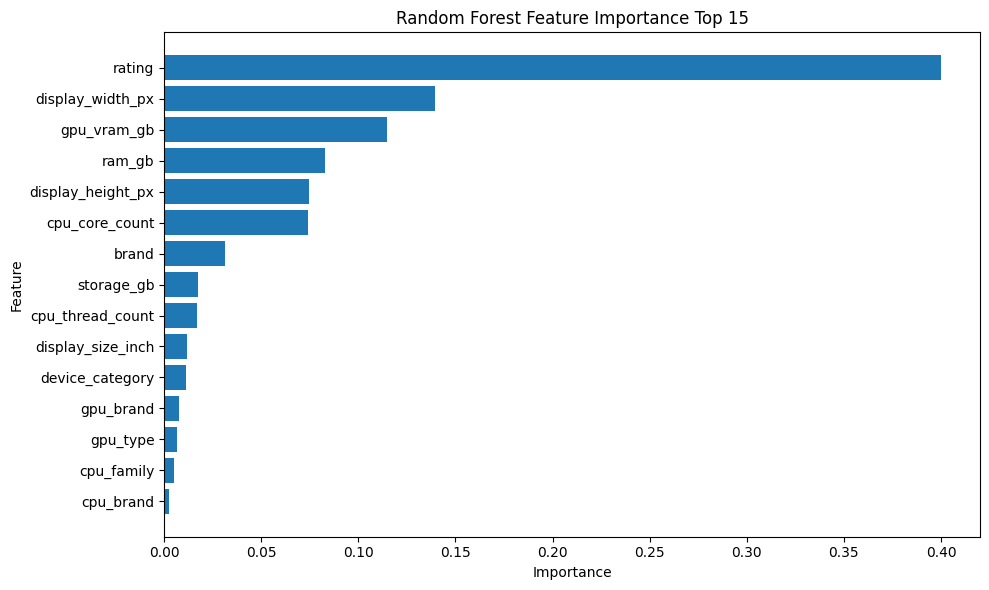

Saved plot to: ..\outputs\figures\random_forest_feature_importance_top15.png


In [ ]:
# Plot the feature importance for the t 15 features
top_n = 15
top_features = grouped_feature_importance_df.head(top_n).sort_values(by="importance")

# horizontal bar plot for the top features
plt.figure(figsize=(10, 6))
plt.barh(top_features["raw_feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Random Forest Feature Importance Top {top_n}")
plt.tight_layout()

# Save the plot to figures directory
rf_importance_plot_path = FIGURES_DIR / "random_forest_feature_importance_top15.png"
plt.savefig(rf_importance_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to: {rf_importance_plot_path}")

Saved: ..\outputs\figures\random_forest_actual_vs_predicted_v1.png


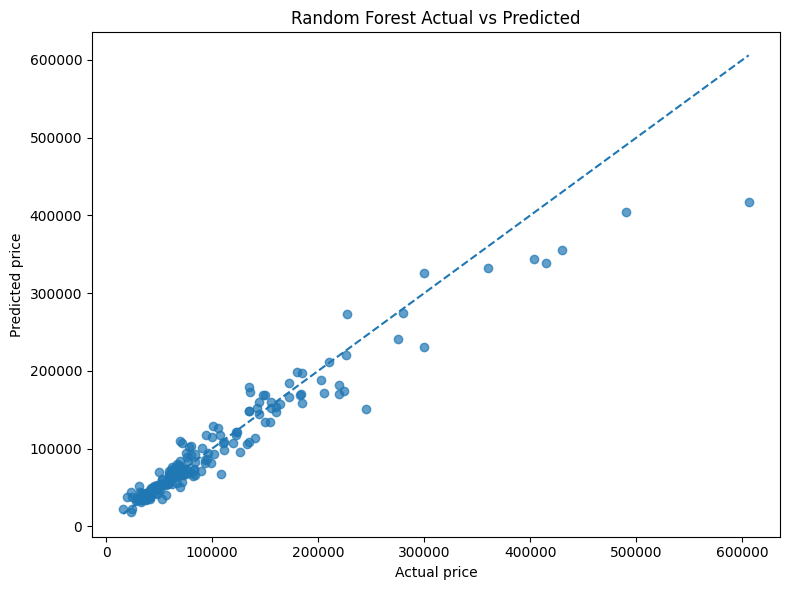

In [ ]:
# Plot actual vs predicted values for rf model
rf_actual = y_test.reset_index(drop=True)
rf_pred = pd.Series(test_predictions_v2["RandomForest"]).reset_index(drop=True)

rf_actual_pred_plot_path = FIGURES_DIR / "random_forest_actual_vs_predicted_v1.png"
plot_actual_vs_predicted(rf_actual, rf_pred, "Random Forest", rf_actual_pred_plot_path)

Saved: ..\outputs\figures\random_forest_residual_plot_v1.png


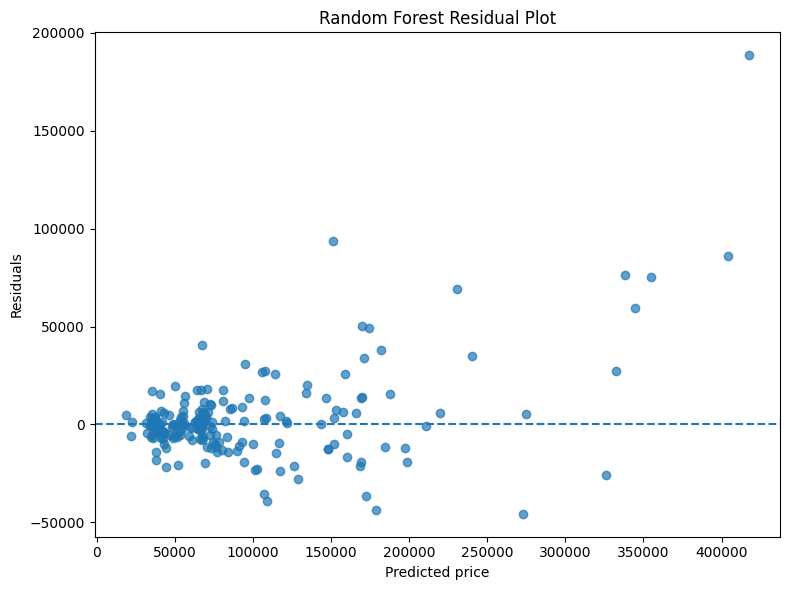

In [ ]:
# Plot residuals for rf model
rf_residual_plot_path = FIGURES_DIR / "random_forest_residual_plot_v1.png"
plot_residuals(rf_actual, rf_pred, "Random Forest", rf_residual_plot_path)

In [ ]:
from sklearn.neural_network import MLPRegressor

In [ ]:
# Define new model with a mlp regressor and the linear preprocessor
def make_dense_onehot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer_mlp = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", make_dense_onehot())
])

numeric_transformer_mlp = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_mlp = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_mlp, numeric_features),
        ("cat", categorical_transformer_mlp, categorical_features),
    ],
    remainder="drop",
    sparse_threshold=0
)

print("MLP preprocessor created.")

MLP preprocessor created.


In [ ]:
# Define two versions of mlp regressor with different architectures and training parameters
mlp_v1 = Pipeline(steps=[
    ("preprocessor", preprocessor_mlp),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=500,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

mlp_v2 = Pipeline(steps=[
    ("preprocessor", preprocessor_mlp),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=800,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=25
    ))
])

# Add new mlp models to the models dictionary for evaluation
models_v3 = {
    "DummyRegressor": DummyRegressor(strategy="mean"),
    "Ridge": Pipeline(steps=[
        ("preprocessor", preprocessor_linear),
        ("model", Ridge(alpha=1.0))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    "MLP_v1": mlp_v1,
    "MLP_v2": mlp_v2
}

print(models_v3.keys())

dict_keys(['DummyRegressor', 'Ridge', 'RandomForest', 'MLP_v1', 'MLP_v2'])


In [ ]:
# Evaluate models and results. Test predictions for new set of models including mlp regressors
results_v3 = []
fitted_models_v3 = {}
test_predictions_v3 = {}

for model_name, model in models_v3.items():
    result, fitted_model, y_pred = evaluate_regressor(
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        cv=cv,
        model_name=model_name
    )

    results_v3.append(result)
    fitted_models_v3[model_name] = fitted_model
    test_predictions_v3[model_name] = y_pred

model_comparison_v3 = (
    pd.DataFrame(results_v3)
    .sort_values(by="test_rmse", ascending=True)
    .reset_index(drop=True)
)

model_comparison_v3

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,Ridge,20616.708270,772.328554,13508.843119,480.360921,0.892535,0.013536,18899.182942,13544.408959,0.951087
1,MLP_v2,22850.717876,1074.005467,14938.996535,1047.128035,0.867612,0.020482,19750.219043,14299.907194,0.946582
2,RandomForest,18687.778204,1463.715362,11374.818742,904.170832,0.910944,0.018086,23678.319671,12900.526213,0.923221
3,DummyRegressor,63407.589211,2744.891777,42614.173500,1820.671897,-0.008106,0.009222,86279.191190,53148.974133,-0.019418
4,MLP_v1,106240.577287,3623.991892,85346.864811,4548.265488,-1.845702,0.278037,129456.748132,97251.309635,-1.295036


In [ ]:
# Display the model comparison df with formatting for better readability
display_metrics_table(model_comparison_v3, METRICS_FORMAT)

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,Ridge,20616.71,772.33,13508.84,480.36,0.8925,0.0135,18899.18,13544.41,0.9511
1,MLP_v2,22850.72,1074.01,14939.00,1047.13,0.8676,0.0205,19750.22,14299.91,0.9466
2,RandomForest,18687.78,1463.72,11374.82,904.17,0.9109,0.0181,23678.32,12900.53,0.9232
3,DummyRegressor,63407.59,2744.89,42614.17,1820.67,-0.0081,0.0092,86279.19,53148.97,-0.0194
4,MLP_v1,106240.58,3623.99,85346.86,4548.27,-1.8457,0.2780,129456.75,97251.31,-1.2950


In [ ]:
# Save the model comparison df to csv
comparison_v3_path = METRICS_DIR / "model_comparison_v3.csv"
save_metrics(model_comparison_v3, comparison_v3_path)

Saved: ..\outputs\metrics\model_comparison_v3.csv


In [ ]:
# Extract training details from the mlp models for debugging and analysis
mlp_debug_rows = []

for model_name in ["MLP_v1", "MLP_v2"]:
    fitted_pipeline = fitted_models_v3[model_name]
    mlp_model = fitted_pipeline.named_steps["model"]

    mlp_debug_rows.append({
        "model": model_name,
        "n_iter": mlp_model.n_iter_,
        "final_loss": mlp_model.loss_,
        "best_validation_score": getattr(mlp_model, "best_validation_score_", None)
    })

mlp_debug_df = pd.DataFrame(mlp_debug_rows)
mlp_debug_df

,model,n_iter,final_loss,best_validation_score
0,MLP_v1,22,5.431145e+09,-1.352582
1,MLP_v2,774,1.932023e+08,0.912771


In [ ]:
# Save the mlp debug info to csv    
mlp_debug_path = METRICS_DIR / "mlp_debug_info.csv"
mlp_debug_df.to_csv(mlp_debug_path, index=False)

print(f"Saved MLP debug info to: {mlp_debug_path}")

Saved MLP debug info to: ..\outputs\metrics\mlp_debug_info.csv


Saved: ..\outputs\figures\model_comparison_test_rmse_v3.png


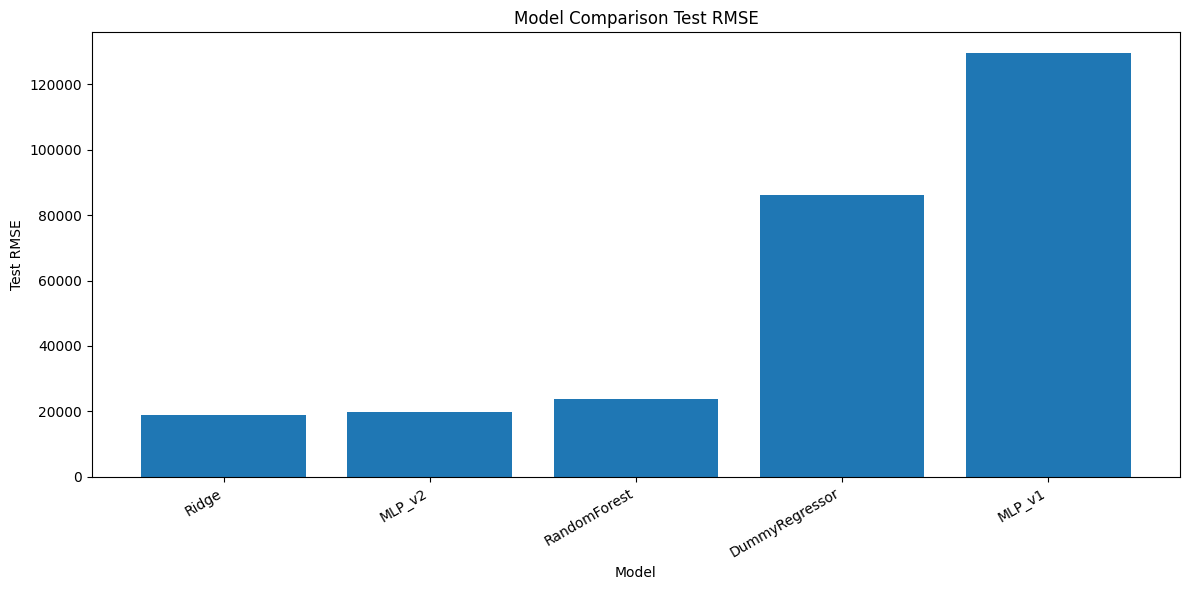

In [ ]:
# Plot the test rmse for all models in the comparison
rmse_plot_path = FIGURES_DIR / "model_comparison_test_rmse_v3.png"
plot_test_rmse_comparison(model_comparison_v3, rmse_plot_path)

In [ ]:
# Prepare for EDA and feature engineering
df_work = df.copy()

print("Working shape:", df_work.shape)

Working shape: (992, 27)


In [ ]:
# Check for fully duplicated rows in working df
duplicate_count = df_work.duplicated().sum()
print("Number of fully duplicated rows:", duplicate_count)

if duplicate_count > 0:
    display(df_work[df_work.duplicated()].head(10))

Number of fully duplicated rows: 0


In [ ]:
# Create a summary of missing values in the working df
missing_summary = pd.DataFrame({
    "missing_count": df_work.isnull().sum(),
    "missing_pct": (df_work.isnull().mean() * 100).round(2),
    "dtype": df_work.dtypes.astype(str)
}).sort_values(by="missing_pct", ascending=False)

display(missing_summary)

,missing_count,missing_pct,dtype
cpu_lp_e_cores,826,83.27,float64
gpu_vram_gb,700,70.56,float64
cpu_e_cores,311,31.35,float64
cpu_p_cores,289,29.13,float64
cpu_suffix,131,13.21,object
gpu_model,8,0.81,object
gpu_series,8,0.81,object
gpu_type,8,0.81,object
gpu_brand,8,0.81,object
model,0,0.00,object


In [ ]:
# Perform plausibility checks on numeric columns to identify potential data quality issues
plausibility_checks = {
    "price_non_positive": (df_work["price"] <= 0).sum(),
    "rating_negative": (df_work["rating"] < 0).sum(),
    "ram_non_positive": (df_work["ram_gb"] <= 0).sum(),
    "storage_non_positive": (df_work["storage_gb"] <= 0).sum(),
    "display_size_non_positive": (df_work["display_size_inch"] <= 0).sum(),
    "display_width_non_positive": (df_work["display_width_px"] <= 0).sum(),
    "display_height_non_positive": (df_work["display_height_px"] <= 0).sum(),
    "cpu_core_count_non_positive": (df_work["cpu_core_count"] <= 0).sum(),
    "cpu_thread_count_non_positive": (df_work["cpu_thread_count"] <= 0).sum(),
    "gpu_vram_negative": (df_work["gpu_vram_gb"].fillna(0) < 0).sum(),
    "warranty_negative": (df_work["warranty_years"] < 0).sum(),
}

plausibility_df = pd.DataFrame(
    plausibility_checks.items(),
    columns=["check", "count"]
)

display(plausibility_df)

,check,count
0,price_non_positive,0
1,rating_negative,0
2,ram_non_positive,0
3,storage_non_positive,0
4,display_size_non_positive,0
5,display_width_non_positive,0
6,display_height_non_positive,0
7,cpu_core_count_non_positive,0
8,cpu_thread_count_non_positive,0
9,gpu_vram_negative,0


In [ ]:
# Identify rows that fail any of the plausibility checks for further inspection
bad_rows = df_work[
    (df_work["price"] <= 0) |
    (df_work["ram_gb"] <= 0) |
    (df_work["storage_gb"] <= 0) |
    (df_work["display_size_inch"] <= 0) |
    (df_work["display_width_px"] <= 0) |
    (df_work["display_height_px"] <= 0) |
    (df_work["cpu_core_count"] <= 0) |
    (df_work["cpu_thread_count"] <= 0) |
    (df_work["warranty_years"] < 0)
]

print("Rows with obvious plausibility issues:", bad_rows.shape[0])
display(bad_rows.head(20))

Rows with obvious plausibility issues: 0


,brand,model,device_category,price,rating,cpu_brand,cpu_family,cpu_series,cpu_model,cpu_suffix,...,display_width_px,display_height_px,display_size_inch,gpu_brand,gpu_series,gpu_model,gpu_vram_gb,gpu_type,os_name,warranty_years


In [ ]:
# Trim annoying whitespace in object columns and replace "nan" strings with actual NaN values
object_cols = df_work.select_dtypes(include="object").columns.tolist()

for col in object_cols:
    df_work[col] = df_work[col].astype(str).str.strip()
    df_work[col] = df_work[col].replace({"nan": np.nan})

print("Trimmed whitespace in object columns.")

Trimmed whitespace in object columns.


In [ ]:
# Check cardinality of obj columns to identify potential issues with high cardinality features
cardinality_df = pd.DataFrame({
    "column": object_cols,
    "n_unique": [df_work[col].nunique(dropna=True) for col in object_cols]
}).sort_values(by="n_unique", ascending=False)

display(cardinality_df)

,column,n_unique
1,model,992
6,cpu_model,119
10,gpu_model,38
5,cpu_series,24
0,brand,19
7,cpu_suffix,11
9,gpu_series,10
4,cpu_family,7
12,os_name,6
8,gpu_brand,5


In [ ]:
# Make decisions on which columns to include in the baseline model and to test later and which to exclude based on the eda findings
column_decisions = pd.DataFrame([
    {
        "column": "model",
        "status": "exclude_from_main_model",
        "reason": "Very close to a product identifier and may reduce generalisation to unseen laptops."
    },
    {
        "column": "cpu_model",
        "status": "test_later",
        "reason": "Potentially useful but likely high-cardinality and may encourage memorisation."
    },
    {
        "column": "gpu_model",
        "status": "test_later",
        "reason": "Potentially useful but likely high-cardinality and may encourage memorisation."
    },
    {
        "column": "cpu_lp_e_cores",
        "status": "drop_candidate",
        "reason": "Too much missingness to justify inclusion in the baseline pipeline."
    },
    {
        "column": "cpu_p_cores",
        "status": "test_later",
        "reason": "Structured missingness likely. Better evaluated in Feature Set B with imputation and missing flags."
    },
    {
        "column": "cpu_e_cores",
        "status": "test_later",
        "reason": "Not empty enough to drop, but not stable enough for the baseline set."
    },
    {
        "column": "gpu_vram_gb",
        "status": "keep",
        "reason": "Missingness may be informative, especially for integrated or lower-end GPU setups."
    },
    {
        "column": "cpu_suffix",
        "status": "exclude_from_main_model",
        "reason": "May add detail, but not essential for the robust baseline and could increase sparsity."
    },
    {
        "column": "cpu_series",
        "status": "test_later",
        "reason": "Useful intermediate detail level, planned for Feature Set B."
    },
    {
        "column": "gpu_series",
        "status": "test_later",
        "reason": "Useful intermediate detail level, planned for Feature Set B."
    },
])

display(column_decisions)

,column,status,reason
0,model,exclude_from_main_model,Very close to a product identifier and may red...
1,cpu_model,test_later,Potentially useful but likely high-cardinality...
2,gpu_model,test_later,Potentially useful but likely high-cardinality...
3,cpu_lp_e_cores,drop_candidate,Too much missingness to justify inclusion in t...
4,cpu_p_cores,test_later,Structured missingness likely. Better evaluate...
5,cpu_e_cores,test_later,"Not empty enough to drop, but not stable enoug..."
6,gpu_vram_gb,keep,"Missingness may be informative, especially for..."
7,cpu_suffix,exclude_from_main_model,"May add detail, but not essential for the robu..."
8,cpu_series,test_later,"Useful intermediate detail level, planned for ..."
9,gpu_series,test_later,"Useful intermediate detail level, planned for ..."


In [ ]:
# Prepare refined df with feature engineering
df_refined = df_work.copy()

print("Refined shape:", df_refined.shape)

Refined shape: (992, 27)


In [ ]:
# Feature engineering based on EDA to create features that may capture important aspects of the laptops and their pricing

df_refined["total_pixels"] = df_refined["display_width_px"] * df_refined["display_height_px"]

df_refined["ppi"] = np.sqrt(
    df_refined["display_width_px"] ** 2 + df_refined["display_height_px"] ** 2
) / df_refined["display_size_inch"]

df_refined["threads_per_core"] = (
    df_refined["cpu_thread_count"] / df_refined["cpu_core_count"]
).replace([np.inf, -np.inf], np.nan)

df_refined["has_dedicated_gpu"] = np.where(
    (df_refined["gpu_type"].fillna("Unknown").str.lower().str.contains("dedicated")) |
    (df_refined["gpu_vram_gb"].fillna(0) > 0),
    1,
    0
)

df_refined["gpu_vram_missing_flag"] = df_refined["gpu_vram_gb"].isna().astype(int)
df_refined["cpu_p_cores_missing_flag"] = df_refined["cpu_p_cores"].isna().astype(int)
df_refined["cpu_e_cores_missing_flag"] = df_refined["cpu_e_cores"].isna().astype(int)

df_refined.head()

,brand,model,device_category,price,rating,cpu_brand,cpu_family,cpu_series,cpu_model,cpu_suffix,...,gpu_type,os_name,warranty_years,total_pixels,ppi,threads_per_core,has_dedicated_gpu,gpu_vram_missing_flag,cpu_p_cores_missing_flag,cpu_e_cores_missing_flag
0,lenovo,Lenovo Legion Pro 5 16IAX10 83F3007CIN Gaming,Gaming,189990,84,Intel,Core Ultra,Core Ultra 7,255HX,HX,...,Dedicated,Windows,1,4096000,188.679623,1.0,1,0,0,0
1,lenovo,Lenovo IdeaPad Slim 3 83K100HSIN,Thin & Light,62350,54,Intel,Core,Core I5,13420H,H,...,Integrated,Windows,1,2073600,146.860478,1.5,0,1,0,0
2,asus,Asus Vivobook Go 15 E1504FA-BQ2343WS,Thin & Light,34990,51,AMD,Ryzen,Ryzen 3,7320U,U,...,Integrated,Windows,1,2073600,146.860478,2.0,0,1,1,1
3,lenovo,Lenovo V14 G3 82TS00JGUS,General,56990,48,Intel,Core,Core I7,1255U,U,...,Integrated,Windows,1,2073600,157.350512,1.2,0,1,0,0
4,dell,Dell DC 14250 ODC1425000401RINS1,General,69990,52,Intel,Core,Core 5,120U,U,...,Integrated,Windows,1,2073600,157.350512,1.2,0,1,0,0


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

if "data_path" in globals():
    project_root = data_path.parent.parent.parent.resolve()
else:
    project_root = next(
        (candidate.resolve() for candidate in [Path("."), Path("..")] if (candidate / "data").exists()),
        Path(".").resolve()
    )

figures_dir = project_root / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

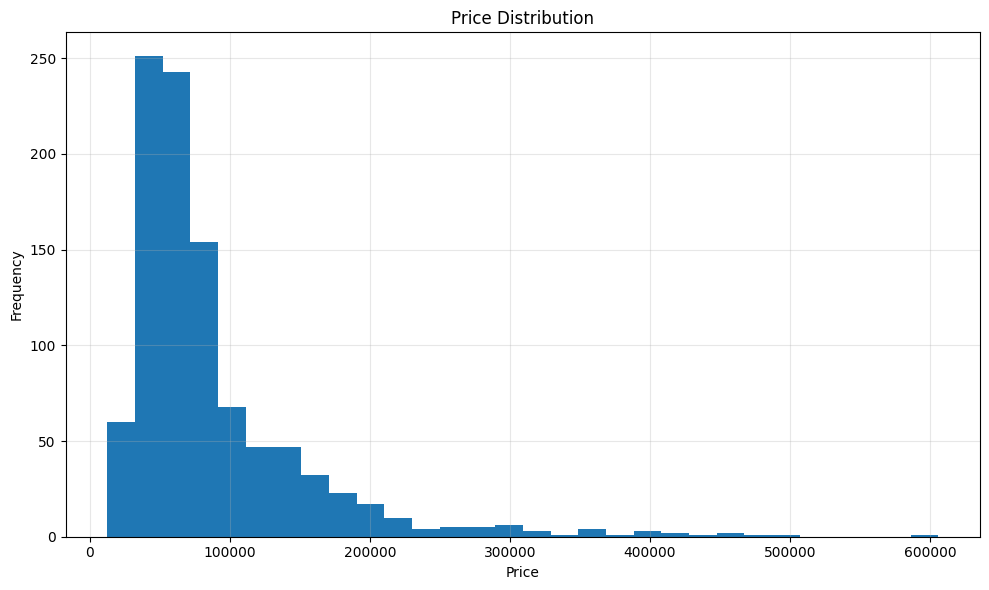

In [ ]:
plot_df = df_refined.copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(plot_df["price"].dropna(), bins=30)
ax.set_title("Price Distribution")
ax.set_xlabel("Price")
ax.set_ylabel("Frequency")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(figures_dir / "price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

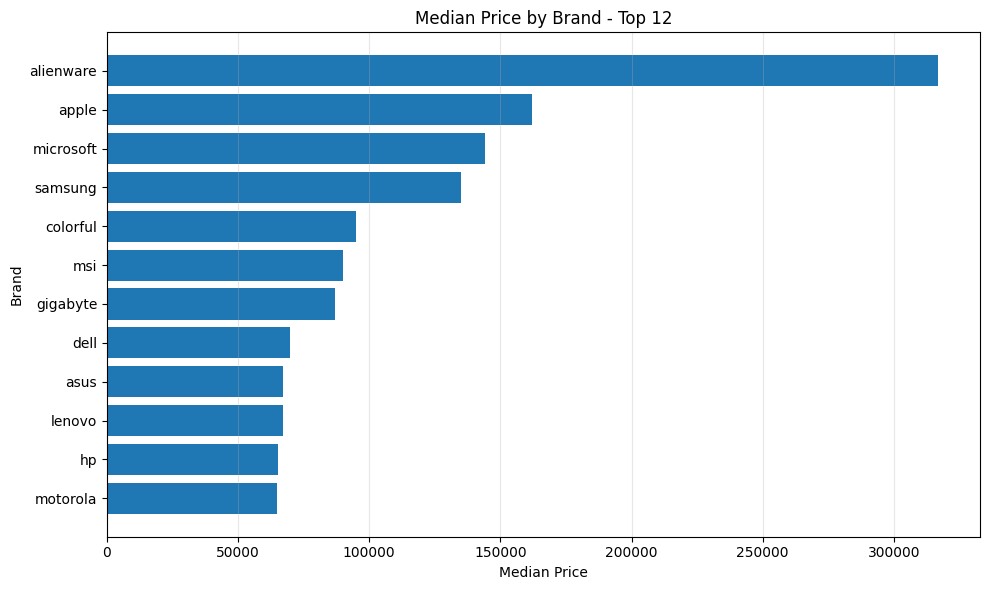

In [ ]:
# plot median price by brand to spot pricing patterns across manufacturers
plot_df = df_refined.copy()

brand_summary = (
    plot_df.dropna(subset=["brand", "price"])
    .groupby("brand", as_index=False)["price"]
    .median()
    .sort_values("price", ascending=False)
)

top_n = 12
brand_summary = brand_summary.head(top_n).sort_values("price", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(brand_summary["brand"], brand_summary["price"])
ax.set_title(f"Median Price by Brand Top {top_n}")
ax.set_xlabel("Median Price")
ax.set_ylabel("Brand")
ax.grid(True, axis="x", alpha=0.3)

fig.tight_layout()
fig.savefig(figures_dir / "price_by_brand.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


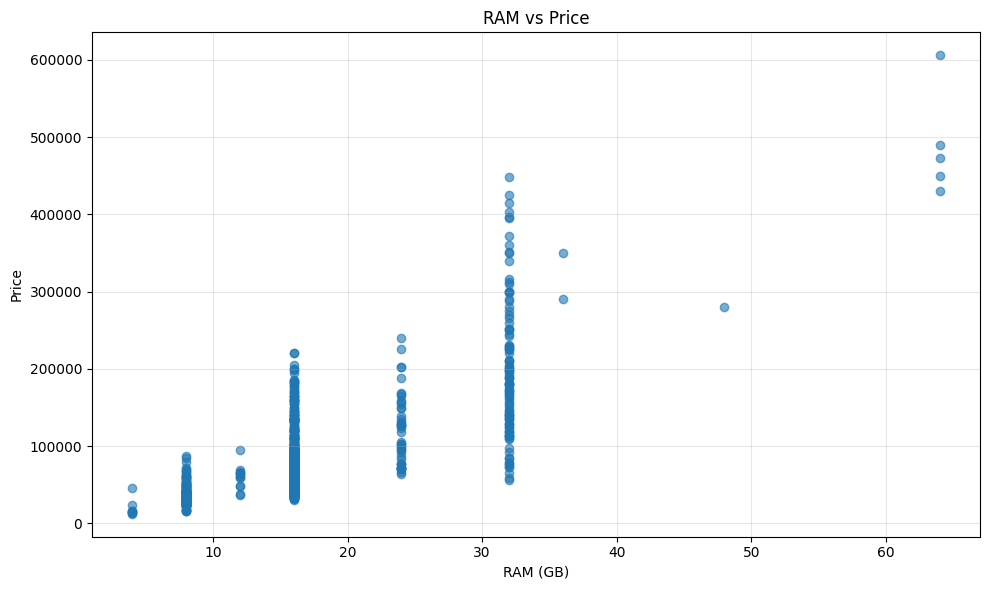

In [ ]:
# Scatter plot to inspect relationship between RAM size and price 
plot_df = df_refined.copy()

scatter_df = plot_df.dropna(subset=["ram_gb", "price"]).copy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(scatter_df["ram_gb"], scatter_df["price"], alpha=0.6)
ax.set_title("RAM vs Price")
ax.set_xlabel("RAM (GB)")
ax.set_ylabel("Price")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(figures_dir / "ram_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


In [ ]:
# Define feature set for next phase of modeling based on the EDA findings and feature engineering. Added some of the new featuresand some of the original features that were not dropped
feature_set_b = [
    "brand",
    "device_category",
    "rating",
    "cpu_brand",
    "cpu_family",
    "cpu_series",
    "cpu_core_count",
    "cpu_thread_count",
    "cpu_p_cores",
    "cpu_e_cores",
    "ram_gb",
    "storage_gb",
    "display_width_px",
    "display_height_px",
    "display_size_inch",
    "gpu_brand",
    "gpu_series",
    "gpu_type",
    "gpu_vram_gb",
    "os_name",
    "warranty_years",
    "total_pixels",
    "ppi",
    "threads_per_core",
    "has_dedicated_gpu",
    "gpu_vram_missing_flag",
    "cpu_p_cores_missing_flag",
    "cpu_e_cores_missing_flag",
]

feature_set_b_no_rating = [col for col in feature_set_b if col != "rating"]

print("Feature Set B size:", len(feature_set_b))
print("Feature Set B without rating size:", len(feature_set_b_no_rating))

Feature Set B size: 28
Feature Set B without rating size: 27


In [ ]:
# Check for missing columns in the df for feature set B

def make_dense_onehot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

In [ ]:
# Function to build preprocessors for the given feature set. Creating separate preprocessors for linear models, tree-based models, MLPs based on characteristics of features and requirements of the models
def build_preprocessors(X):
    numeric_features_local = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_features_local = X.select_dtypes(exclude=["number"]).columns.tolist()

    categorical_transformer_sparse = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    categorical_transformer_dense = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", make_dense_onehot())
    ])

    numeric_transformer_linear = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    numeric_transformer_tree = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    numeric_transformer_mlp = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    preprocessor_linear_local = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer_linear, numeric_features_local),
            ("cat", categorical_transformer_sparse, categorical_features_local),
        ]
    )

    preprocessor_tree_local = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer_tree, numeric_features_local),
            ("cat", categorical_transformer_sparse, categorical_features_local),
        ]
    )

    preprocessor_mlp_local = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer_mlp, numeric_features_local),
            ("cat", categorical_transformer_dense, categorical_features_local),
        ],
        sparse_threshold=0
    )

    return (
        numeric_features_local,
        categorical_features_local,
        preprocessor_linear_local,
        preprocessor_tree_local,
        preprocessor_mlp_local
    )

In [ ]:
# Function to run a feature experiment given a df, a list of features to use and label for the experiment.
def run_feature_experiment(df_input, feature_list, label):
    X = df_input[feature_list].copy()
    y = df_input["price"].copy()

    X_train_local, X_test_local, y_train_local, y_test_local = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    (
        numeric_features_local,
        categorical_features_local,
        preprocessor_linear_local,
        preprocessor_tree_local,
        preprocessor_mlp_local
    ) = build_preprocessors(X_train_local)

    models_local = {
        f"Ridge_{label}": Pipeline(steps=[
            ("preprocessor", preprocessor_linear_local),
            ("model", Ridge(alpha=1.0))
        ]),
        f"RandomForest_{label}": Pipeline(steps=[
            ("preprocessor", preprocessor_tree_local),
            ("model", RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        f"MLP_v2_{label}": Pipeline(steps=[
            ("preprocessor", preprocessor_mlp_local),
            ("model", MLPRegressor(
                hidden_layer_sizes=(128, 64),
                activation="relu",
                solver="adam",
                alpha=0.001,
                learning_rate_init=0.001,
                max_iter=800,
                random_state=RANDOM_STATE,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=25
            ))
        ])
    }

    rows = []
    fitted_models_local = {}
    predictions_local = {}

    for model_name, model in models_local.items():
        result, fitted_model, y_pred = evaluate_regressor(
            model=model,
            X_train=X_train_local,
            y_train=y_train_local,
            X_test=X_test_local,
            y_test=y_test_local,
            cv=cv,
            model_name=model_name
        )
        rows.append(result)
        fitted_models_local[model_name] = fitted_model
        predictions_local[model_name] = y_pred

    result_df = pd.DataFrame(rows).sort_values("test_rmse").reset_index(drop=True)

    return result_df, fitted_models_local, predictions_local, X_train_local, X_test_local, y_train_local, y_test_local

In [ ]:
# Run the feature experiment with feature set B and the refined df
results_b, models_b, preds_b, X_train_b, X_test_b, y_train_b, y_test_b = run_feature_experiment(
    df_input=df_refined,
    feature_list=feature_set_b,
    label="feature_set_b"
)

display_metrics_table(results_b, METRICS_FORMAT)

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,MLP_v2_feature_set_b,21932.94,1615.10,13784.01,811.38,0.8771,0.0275,17937.84,12231.07,0.9559
1,Ridge_feature_set_b,19892.26,1097.25,12599.67,609.60,0.9000,0.0132,18675.55,12834.10,0.9522
2,RandomForest_feature_set_b,18226.63,1485.23,10941.60,882.49,0.9153,0.0176,23586.18,12630.23,0.9238


In [ ]:
# Run the feature experiment with feature set B without rating feature
results_b_no_rating, models_b_no_rating, preds_b_no_rating, X_train_b_nr, X_test_b_nr, y_train_b_nr, y_test_b_nr = run_feature_experiment(
    df_input=df_refined,
    feature_list=feature_set_b_no_rating,
    label="feature_set_b_no_rating"
)

display_metrics_table(results_b_no_rating, METRICS_FORMAT)

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,MLP_v2_feature_set_b_no_rating,22350.97,1672.69,13989.95,909.91,0.8721,0.0295,19807.77,13773.21,0.9463
1,Ridge_feature_set_b_no_rating,20155.72,1059.48,12549.14,635.33,0.8974,0.0131,19851.97,12829.06,0.9460
2,RandomForest_feature_set_b_no_rating,18200.87,1296.29,10700.56,830.85,0.9155,0.0171,23872.31,12162.19,0.9220


In [ ]:
# Save the results of the feature set experiments
results_b_path = METRICS_DIR / "model_comparison_feature_set_b.csv"
results_b_no_rating_path = METRICS_DIR / "model_comparison_feature_set_b_no_rating.csv"

results_b.to_csv(results_b_path, index=False)
results_b_no_rating.to_csv(results_b_no_rating_path, index=False)

print(f"Saved: {results_b_path}")
print(f"Saved: {results_b_no_rating_path}")

Saved: ..\outputs\metrics\model_comparison_feature_set_b.csv
Saved: ..\outputs\metrics\model_comparison_feature_set_b_no_rating.csv


In [ ]:
# Create a combined comparison of all models from the different experiments.
combined_model_comparison = pd.concat(
    [
        model_comparison_v3,
        results_b,
        results_b_no_rating
    ],
    ignore_index=True
).sort_values(by="test_rmse", ascending=True).reset_index(drop=True)

combined_model_comparison

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,MLP_v2_feature_set_b,21932.941119,1615.100155,13784.012663,811.379960,0.877054,0.027500,17937.836030,12231.072114,0.955936
1,Ridge_feature_set_b,19892.260924,1097.250037,12599.674072,609.602558,0.899973,0.013238,18675.551527,12834.102468,0.952238
2,Ridge,20616.708270,772.328554,13508.843119,480.360921,0.892535,0.013536,18899.182942,13544.408959,0.951087
3,MLP_v2,22850.717876,1074.005467,14938.996535,1047.128035,0.867612,0.020482,19750.219043,14299.907194,0.946582
4,MLP_v2_feature_set_b_no_rating,22350.969470,1672.694811,13989.950001,909.909383,0.872064,0.029462,19807.768337,13773.205153,0.946271
5,Ridge_feature_set_b_no_rating,20155.720848,1059.483630,12549.139934,635.331922,0.897368,0.013065,19851.971864,12829.056046,0.946031
6,RandomForest_feature_set_b,18226.628056,1485.226708,10941.596124,882.489853,0.915258,0.017557,23586.179527,12630.234502,0.923817
7,RandomForest,18687.778204,1463.715362,11374.818742,904.170832,0.910944,0.018086,23678.319671,12900.526213,0.923221
8,RandomForest_feature_set_b_no_rating,18200.873091,1296.293095,10700.557663,830.848070,0.915508,0.017086,23872.310760,12162.190307,0.921958
9,DummyRegressor,63407.589211,2744.891777,42614.173500,1820.671897,-0.008106,0.009222,86279.191190,53148.974133,-0.019418


In [ ]:
# Save the combined comparison to csv
combined_comparison_path = METRICS_DIR / "model_comparison_combined.csv"
combined_model_comparison.to_csv(combined_comparison_path, index=False)

print(f"Saved: {combined_comparison_path}")

Saved: ..\outputs\metrics\model_comparison_combined.csv


Saved: ..\outputs\figures\model_comparison_combined_test_rmse.png


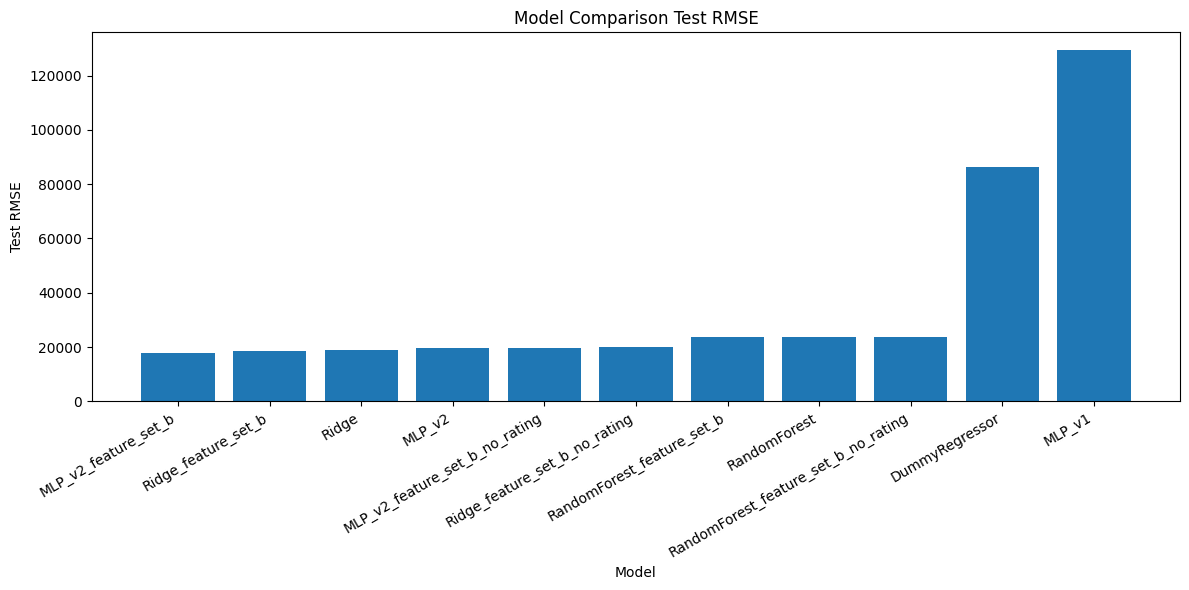

In [ ]:
# Create a bar plot of the test RMSE for each model
combined_rmse_plot_path = FIGURES_DIR / "model_comparison_combined_test_rmse.png"
plot_test_rmse_comparison(combined_model_comparison, combined_rmse_plot_path, figsize=(12, 6))

In [ ]:
# Identify the best model by test RMSE in the current combined comparison and print its name
best_model_name = combined_model_comparison.iloc[0]["model"]
print("Best model by test RMSE in current comparison:", best_model_name)

Best model by test RMSE in current comparison: MLP_v2_feature_set_b


Saved: ..\outputs\figures\best_model_actual_vs_predicted.png


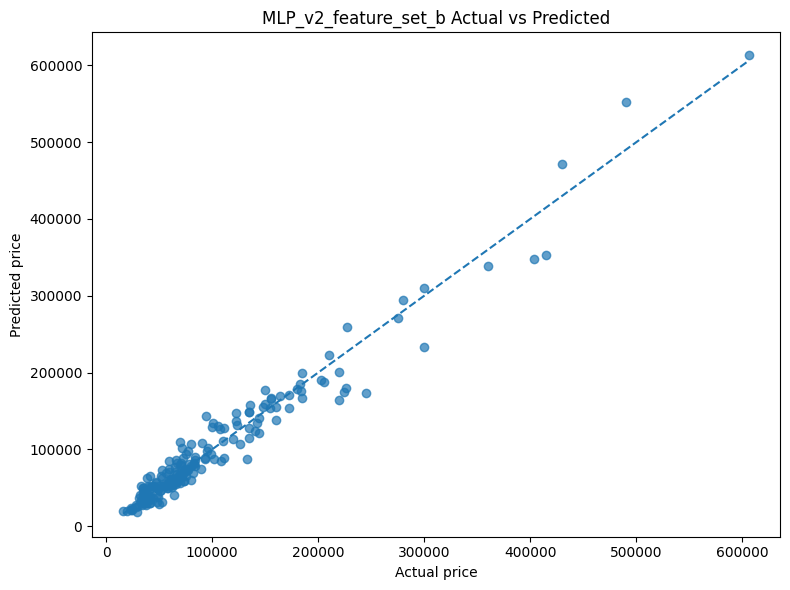

In [ ]:
# Plot actual vs predicted for the best model if available
if best_model_name in results_b["model"].values:
    y_actual_best = y_test_b.reset_index(drop=True)
    y_pred_best = pd.Series(preds_b[best_model_name]).reset_index(drop=True)
elif best_model_name in results_b_no_rating["model"].values:
    y_actual_best = y_test_b_nr.reset_index(drop=True)
    y_pred_best = pd.Series(preds_b_no_rating[best_model_name]).reset_index(drop=True)
else:
    y_actual_best = None
    y_pred_best = None

if y_actual_best is not None:
    best_actual_pred_path = FIGURES_DIR / "best_model_actual_vs_predicted.png"
    plot_actual_vs_predicted(y_actual_best, y_pred_best, best_model_name, best_actual_pred_path)
else:
    print("Current best model is from an earlier comparison set.")

Saved: ..\outputs\figures\best_model_residual_plot.png


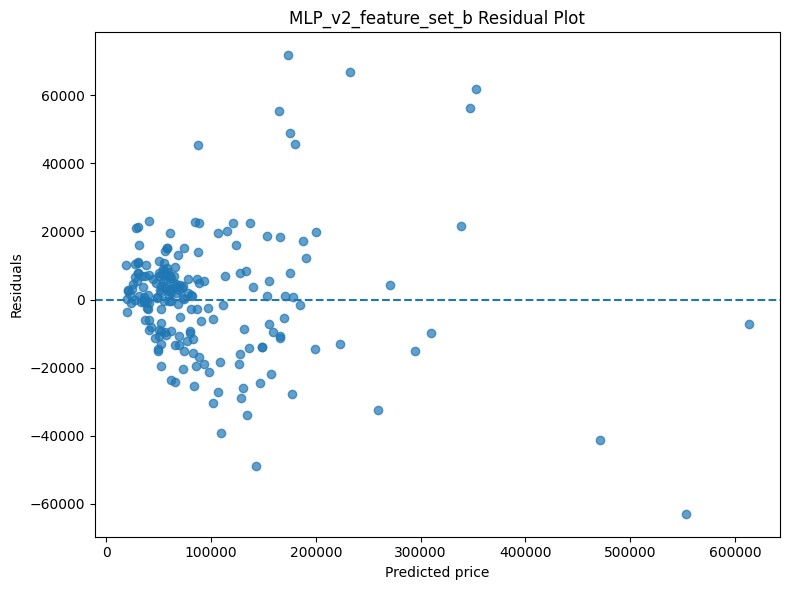

In [ ]:
# Plot residuals for the best model if available
if "y_actual_best" in globals() and y_actual_best is not None:
    best_residual_path = FIGURES_DIR / "best_model_residual_plot.png"
    plot_residuals(y_actual_best, y_pred_best, best_model_name, best_residual_path)
else:
    print("Run the previous best-model prediction plot cell first to generate residuals.")

In [ ]:
# Save the best model to disk for potential later use
from pathlib import Path
import json
import joblib

if "data_path" in globals():
    project_root = data_path.parent.parent.parent.resolve()
else:
    project_root = next(
        (p.resolve() for p in [Path("."), Path("..")] if (p / "data").exists()),
        Path(".").resolve()
    )

ARTIFACTS_DIR = project_root / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Artifacts path:", ARTIFACTS_DIR)

Project root: C:\Users\Felix\Documents\University\Master\Master\COM763 Advanced Machine Learning\Assignments\Assignment 1\Git\streamlit-regression-app
Artifacts path: C:\Users\Felix\Documents\University\Master\Master\COM763 Advanced Machine Learning\Assignments\Assignment 1\Git\streamlit-regression-app\artifacts


In [ ]:
# Save the best model pipeline to disk
final_model_name = "MLP_v2_feature_set_b"
final_feature_list = feature_set_b.copy()

final_selection_reason = {
    "selected_model": final_model_name,
    "reason_short": "Best hold-out test performance after feature refinement.",
    "benchmark_kept_for_report": "Ridge_feature_set_b",
    "selection_basis": {
        "primary": ["test_rmse", "test_mae", "test_r2"],
        "secondary": ["cv_rmse_mean", "cv_r2_mean", "deployment suitability"]
    }
}

final_selection_reason

{'selected_model': 'MLP_v2_feature_set_b',
 'reason_short': 'Best hold-out test performance after feature refinement.',
 'benchmark_kept_for_report': 'Ridge_feature_set_b',
 'selection_basis': {'primary': ['test_rmse', 'test_mae', 'test_r2'],
  'secondary': ['cv_rmse_mean', 'cv_r2_mean', 'deployment suitability']}}

In [ ]:
# Save the final model pipeline
X_final = df_refined[final_feature_list].copy()
y_final = df_refined["price"].copy()

print("Final X shape:", X_final.shape)
print("Final y shape:", y_final.shape)
print("Final feature count:", len(final_feature_list))

Final X shape: (992, 28)
Final y shape: (992,)
Final feature count: 28


In [ ]:
# Split the final dataset into training and testing sets for the final model evaluation and potential later use
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("X_train_final:", X_train_final.shape)
print("X_test_final :", X_test_final.shape)

X_train_final: (793, 28)
X_test_final : (199, 28)


In [ ]:
# Build preprocessors for the final feature set to be used in the final model pipeline
(
    numeric_features_final,
    categorical_features_final,
    _,
    _,
    preprocessor_mlp_final
) = build_preprocessors(X_train_final)

print("Numeric features:", numeric_features_final)
print("Categorical features:", categorical_features_final)

Numeric features: ['rating', 'cpu_core_count', 'cpu_thread_count', 'cpu_p_cores', 'cpu_e_cores', 'ram_gb', 'storage_gb', 'display_width_px', 'display_height_px', 'display_size_inch', 'gpu_vram_gb', 'warranty_years', 'total_pixels', 'ppi', 'threads_per_core', 'has_dedicated_gpu', 'gpu_vram_missing_flag', 'cpu_p_cores_missing_flag', 'cpu_e_cores_missing_flag']
Categorical features: ['brand', 'device_category', 'cpu_brand', 'cpu_family', 'cpu_series', 'gpu_brand', 'gpu_series', 'gpu_type', 'os_name']


In [ ]:
# Define final model pipeline with the MLP regressor and the corresponding preprocessor for final feature set
final_eval_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_mlp_final),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=800,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=25
    ))
])

final_eval_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [ ]:
# Fit the final model pipeline on the training data and evaluate on the test set to get final performance metrics
final_eval_pipeline.fit(X_train_final, y_train_final)
y_pred_final = final_eval_pipeline.predict(X_test_final)

final_test_rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))
final_test_mae = mean_absolute_error(y_test_final, y_pred_final)
final_test_r2 = r2_score(y_test_final, y_pred_final)

final_metrics_df = pd.DataFrame([{
    "model": final_model_name,
    "test_rmse": final_test_rmse,
    "test_mae": final_test_mae,
    "test_r2": final_test_r2,
    "n_train": len(X_train_final),
    "n_test": len(X_test_final),
    "feature_count": len(final_feature_list)
}])

final_metrics_df

,model,test_rmse,test_mae,test_r2,n_train,n_test,feature_count
0,MLP_v2_feature_set_b,17937.83603,12231.072114,0.955936,793,199,28


Saved: ..\outputs\figures\final_model_actual_vs_predicted.png


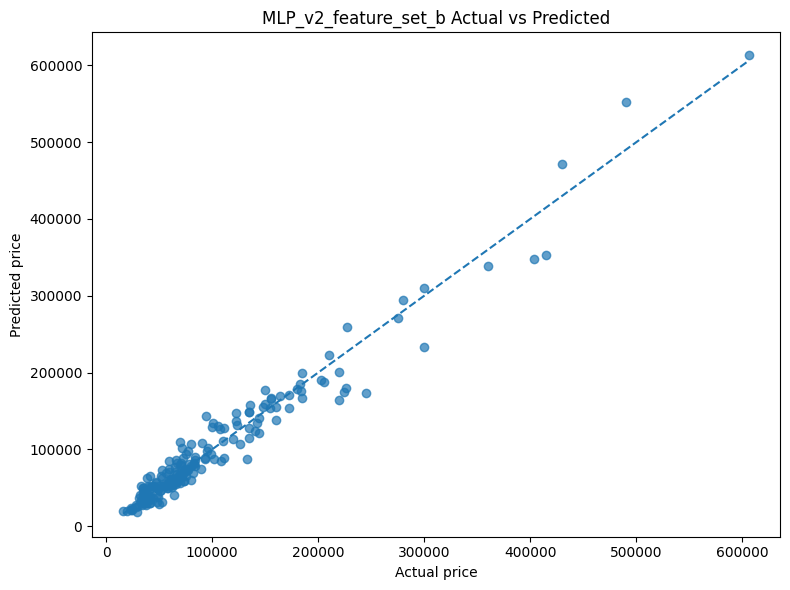

In [ ]:
# Plot actual vs predicted for final model
final_actual_pred_path = FIGURES_DIR / "final_model_actual_vs_predicted.png"
plot_actual_vs_predicted(y_test_final, y_pred_final, final_model_name, final_actual_pred_path)

Saved: ..\outputs\figures\final_model_residual_plot.png


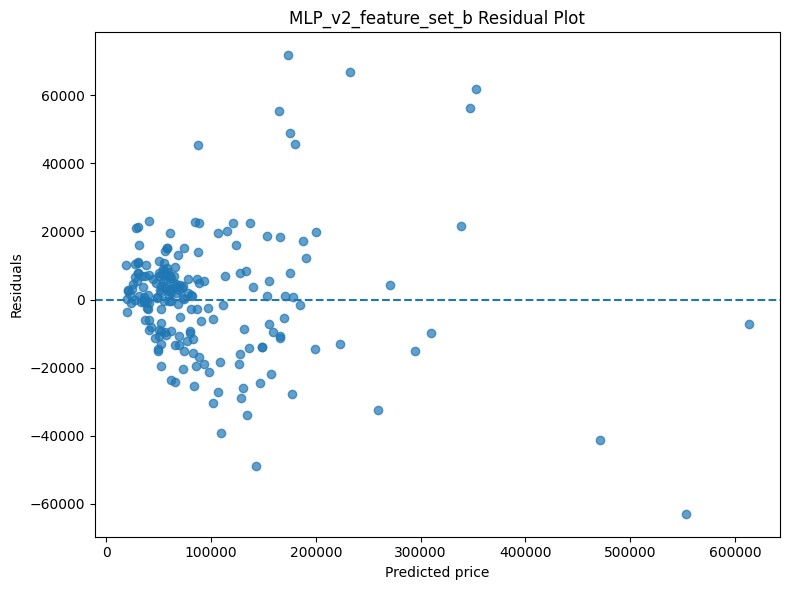

In [ ]:
# Plot residuals for final model
final_residuals = y_test_final - y_pred_final
final_residual_path = FIGURES_DIR / "final_model_residual_plot.png"
plot_residuals(y_test_final, y_pred_final, final_model_name, final_residual_path)

In [ ]:
# Save the final model pipeline to disk for potential later use
final_metrics_path = METRICS_DIR / "final_model_metrics.csv"
final_metrics_df.to_csv(final_metrics_path, index=False)

selection_summary_path = METRICS_DIR / "final_model_selection_summary.json"
with open(selection_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_selection_reason, f, indent=2)

print(f"Saved: {final_metrics_path}")
print(f"Saved: {selection_summary_path}")

Saved: ..\outputs\metrics\final_model_metrics.csv
Saved: ..\outputs\metrics\final_model_selection_summary.json


In [ ]:
# Build and train the final pipeline on the full dataset for deployment
(
    numeric_features_deploy,
    categorical_features_deploy,
    _,
    _,
    preprocessor_mlp_deploy
) = build_preprocessors(X_final)

final_deploy_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_mlp_deploy),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=800,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=25
    ))
])

final_deploy_pipeline.fit(X_final, y_final)

print("Deployable final pipeline trained on full dataset.")


Deployable final pipeline trained on full dataset.


In [ ]:
# UI config for the Streamlit app (labels/options/ranges)
display_names = {
    "brand": "Brand",
    "device_category": "Device Category",
    "rating": "User Rating",
    "cpu_brand": "CPU Brand",
    "cpu_family": "CPU Family",
    "cpu_series": "CPU Series",
    "cpu_core_count": "CPU Core Count",
    "cpu_thread_count": "CPU Thread Count",
    "cpu_p_cores": "CPU P-Cores",
    "cpu_e_cores": "CPU E-Cores",
    "ram_gb": "RAM (GB)",
    "storage_gb": "Storage (GB)",
    "display_width_px": "Display Width (px)",
    "display_height_px": "Display Height (px)",
    "display_size_inch": "Display Size (inch)",
    "gpu_brand": "GPU Brand",
    "gpu_series": "GPU Series",
    "gpu_type": "GPU Type",
    "gpu_vram_gb": "GPU VRAM (GB)",
    "os_name": "Operating System",
    "warranty_years": "Warranty (Years)",
    "total_pixels": "Total Pixels",
    "ppi": "Pixels Per Inch",
    "threads_per_core": "Threads Per Core",
    "has_dedicated_gpu": "Has Dedicated GPU",
    "gpu_vram_missing_flag": "GPU VRAM Missing Flag",
    "cpu_p_cores_missing_flag": "CPU P-Cores Missing Flag",
    "cpu_e_cores_missing_flag": "CPU E-Cores Missing Flag",
}

categorical_options = {}
for col in X_final.select_dtypes(exclude=["number"]).columns:
    values = (
        df_refined[col]
        .dropna()
        .astype(str)
        .sort_values()
        .unique()
        .tolist()
    )
    categorical_options[col] = values

numeric_ranges = {}
for col in X_final.select_dtypes(include=["number"]).columns:
    numeric_ranges[col] = {
        "min": float(np.nanmin(X_final[col])),
        "max": float(np.nanmax(X_final[col])),
        "median": float(np.nanmedian(X_final[col]))
    }

app_config = {
    "target": "price",
    "selected_model": final_model_name,
    "features": final_feature_list,
    "display_names": display_names,
    "categorical_options": categorical_options,
    "numeric_ranges": numeric_ranges,
    "notes": {
        "prediction_type": "Laptop price regression",
        "currency_note": "Predicted price is returned in the dataset currency unit."
    }
}

app_config.keys()

dict_keys(['target', 'selected_model', 'features', 'display_names', 'categorical_options', 'numeric_ranges', 'notes'])

In [ ]:
# Save final pipeline and app config for deployment
final_pipeline_path = ARTIFACTS_DIR / "final_price_pipeline.pkl"
app_config_path = ARTIFACTS_DIR / "app_config.json"

joblib.dump(final_deploy_pipeline, final_pipeline_path)

with open(app_config_path, "w", encoding="utf-8") as f:
    json.dump(app_config, f, indent=2)

print(f"Saved pipeline to: {final_pipeline_path}")
print(f"Saved app config to: {app_config_path}")

Saved pipeline to: C:\Users\Felix\Documents\University\Master\Master\COM763 Advanced Machine Learning\Assignments\Assignment 1\Git\streamlit-regression-app\artifacts\final_price_pipeline.pkl
Saved app config to: C:\Users\Felix\Documents\University\Master\Master\COM763 Advanced Machine Learning\Assignments\Assignment 1\Git\streamlit-regression-app\artifacts\app_config.json


In [ ]:
# sanity checks to ensure artifacts were saved and config can be loaded
print("Pipeline exists:", final_pipeline_path.exists())
print("Config exists   :", app_config_path.exists())

with open(app_config_path, "r", encoding="utf-8") as f:
    app_config_preview = json.load(f)

print("Selected model:", app_config_preview["selected_model"])
print("Number of features:", len(app_config_preview["features"]))

Pipeline exists: True
Config exists   : True
Selected model: MLP_v2_feature_set_b
Number of features: 28


In [ ]:
# sanity check to load the saved pipeline and predict on one sample
loaded_pipeline = joblib.load(final_pipeline_path)

sample_input = X_final.head(1).copy()
sample_prediction = loaded_pipeline.predict(sample_input)[0]

print("Sample prediction:", round(float(sample_prediction), 2))
display(sample_input)

Sample prediction: 225593.4


,brand,device_category,rating,cpu_brand,cpu_family,cpu_series,cpu_core_count,cpu_thread_count,cpu_p_cores,cpu_e_cores,...,gpu_vram_gb,os_name,warranty_years,total_pixels,ppi,threads_per_core,has_dedicated_gpu,gpu_vram_missing_flag,cpu_p_cores_missing_flag,cpu_e_cores_missing_flag
0,lenovo,Gaming,84,Intel,Core Ultra,Core Ultra 7,20,20,8.0,12.0,...,8.0,Windows,1,4096000,188.679623,1.0,1,0,0,0
